# Aranceles de Ecuador a Colombia: impacto sobre exportaciones no minero-energéticas
### Estimación de elasticidad-precio por subpartida HS6

**Autor:** Nicolás Yepes
**Datos:** DANE – Estadísticas de Exportaciones (DEX/DIAN) | Enero 2023 – Diciembre 2025
**Alcance:** Exportaciones no minero-energéticas de Colombia a Ecuador
*(excluye HS2 = 26 minerales, 27 combustibles, 71 metales y piedras preciosas)*

---

## ¿Qué responde este ejercicio?

En 2026, Ecuador aplicó aranceles escalonados sobre importaciones colombianas:
**30% en enero** como medida inicial, y **50% desde febrero** como tasa definitiva.
Este notebook cuantifica el impacto sobre las exportaciones no minero-energéticas
usando elasticidades-precio estimadas con datos históricos 2023–2025.

Responde dos preguntas concretas — y solo esas dos:

| Pregunta | Base de datos | Tipo de resultado |
|----------|---------------|-------------------|
| ¿Qué predijo el modelo para enero 2026 con tau = 30%? | Enero 2025 (real) + elasticidades históricas | Validación puntual contra dato real DANE |
| ¿Cuánto FOB se pierde estructuralmente con tau = 50% (feb–dic)? | Feb–dic 2025 (real) + elasticidades históricas + lambda dinámico | Estimación de impacto — no un forecast de 2026 |

---

## Qué NO hace este modelo

Este **no es un forecast de exportaciones para 2026**. No incorpora crecimiento
económico de Ecuador, tipo de cambio, sustitución de proveedores ni shocks adicionales
de demanda. Proyectar "julio 2026 = $X millones" requeriría modelar todas esas variables
simultáneamente — e introduciría tanta incertidumbre que oscurecería la pregunta central:
*¿cuál es el efecto propio del arancel?*

Lo que el modelo sí puede responder con rigor: dado un shock de precio (el arancel)
aplicado sobre una estructura de comercio real y observada, ¿cuánto cae la cantidad
demandada? Eso es un ejercicio estándar de análisis de política comercial.

---

## Lambda dinámico: adopción gradual del impacto

No todos los agentes reaccionan al arancel de inmediato. Los contratos vigentes,
los inventarios pre-comprados y la inercia comercial hacen que el efecto se acumule
progresivamente. El parámetro **lambda** modela esa velocidad — y es el único
supuesto externo del modelo (no se estima de los datos):

| Trimestre | Lambda | Interpretación económica |
|-----------|--------|--------------------------|
| Ene–Mar | 0.20 | Contratos vigentes, inventarios previos — impacto incipiente |
| Abr–Jun | 0.60 | Nuevos pedidos ya incorporan el costo arancelario |
| Jul–Sep | 0.80 | Mayoría de operaciones bajo el nuevo régimen |
| Oct–Dic | 1.00 | Equilibrio post-arancel consolidado — efecto pleno |

Para sensibilizar este supuesto, basta modificar `LAMBDA_SCHEDULE` en la sección 2.2
y re-ejecutar las Partes 4 y 5. Las elasticidades estimadas no cambian.

---

## Estructura del notebook

```
PARTE 1 — Contexto y hallazgos principales
PARTE 2 — Setup: datos, funciones y modelo
PARTE 3 — Validación: enero 2025 → predicción enero 2026 (tau = 30%)
PARTE 4 — Impacto estructural: base 2025 con tau = 50% (feb–dic) y lambda dinámico
PARTE 5 — Sectores en riesgo: rankings comparativos
PARTE 6 — Metodología, supuestos y limitaciones
```


---
## PARTE 2 — Setup: datos, funciones y modelo

### 2.1 — Imports y configuración visual


In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

BLUE   = "#1F3864"
ORANGE = "#C55A11"
TEAL   = "#2E75B6"
RED    = "#C00000"
GREEN  = "#375623"
PURPLE = "#7030A0"
print("[OK] Imports listos")


[OK] Imports listos


### 2.2 — Parámetros del modelo

#### Tasas arancelarias aplicadas por Ecuador

Ecuador aplicó dos tasas distintas durante 2026:
- **TAU = 30%** — vigente en enero 2026. Se usa exclusivamente en la validación puntual (Parte 3).
- **TAU_50 = 50%** — vigente desde febrero 2026 en adelante. Se usa para la estimación de impacto estructural (Parte 4).

Esta distinción refleja el contexto real: el arancel se endureció a partir del segundo mes.

#### Lambda dinámico: velocidad de adopción del impacto

```
Ene–Mar  lambda = 0.20  →  solo el 20% del impacto se materializa
Abr–Jun  lambda = 0.60  →  60% del impacto
Jul–Sep  lambda = 0.80  →  80% del impacto
Oct–Dic  lambda = 1.00  →  efecto pleno
```

#### Pass-through (phi)

Fracción del arancel que el exportador colombiano traslada efectivamente al precio
que paga el importador ecuatoriano. Se evalúan tres escenarios:
- `phi = 0.6` — traslado parcial: el exportador absorbe el 40% del costo
- `phi = 0.8` — traslado mayoritario
- `phi = 1.0` — traslado completo (escenario central)


In [2]:
# ============================================================
# CONFIGURACIÓN GENERAL DEL PROYECTO
# ============================================================

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR      = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUT_DIR       = DATA_DIR / "marts" / "tariff_ecuador_v6"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR       = OUT_DIR / "figuras"
FIG_DIR.mkdir(exist_ok=True)
GOLD_PARQUET  = PROCESSED_DIR / "exportaciones_final.parquet"

# ── País y clasificación ──────────────────────────────────────────────────────
PAIS_DESTINO   = "ECUADOR"
HS_LEVEL       = 6
YEAR_MIN, YEAR_MAX = 2023, 2025

# ── Parámetros econométricos ─────────────────────────────────────────────────
PANEL_MIN_OBS = 18
WINSOR_P      = 0.02
BETA_MIN      = -3.0
BETA_MAX      = -0.1

# ── Tasas arancelarias ───────────────────────────────────────────────────────
# TAU:    30% — arancel de enero 2026 (solo para validación puntual Parte 3)
# TAU_50: 50% — arancel desde febrero 2026 (para estimación de impacto Parte 4)
TAU    = 0.30
TAU_50 = 0.50

# ── Pass-through ─────────────────────────────────────────────────────────────
PHI_SET     = [0.6, 0.8, 1.0]
PHI_CENTRAL = 1.0

# ── Lambda dinámico: velocidad de adopción mensual ───────────────────────────
# Enero: lambda bajo porque el arancel del 30% recién entró en vigor
# Feb–Mar: también bajo, inventarios previos al 50% aún en circulación
# Q2 en adelante: adopción progresiva del arancel del 50%
LAMBDA_SCHEDULE = {
    1:  0.20,   # Enero   — tau=30%, contratos vigentes, inventarios previos
    2:  0.20,   # Febrero — tau=50% recién iniciado, inventarios aún en uso
    3:  0.20,   # Marzo   — transición Q1
    4:  0.60,   # Abril   — nuevos pedidos incorporan el 50%
    5:  0.60,   # Mayo
    6:  0.60,   # Junio
    7:  0.80,   # Julio   — mayoría de operaciones bajo nuevo régimen
    8:  0.80,   # Agosto
    9:  0.80,   # Septiembre
    10: 1.00,   # Octubre — efecto pleno del 50%
    11: 1.00,   # Noviembre
    12: 1.00,   # Diciembre
}

# Lambda específico para la validación de enero (tau=30%)
LAMBDA_ENERO_VALIDACION = LAMBDA_SCHEDULE[1]

# ── Datos de validación ──────────────────────────────────────────────────────
JAN_2025_REAL = 176_249_194
JAN_2026_REAL = 121_200_000   # ← actualizar con dato definitivo DANE

# ── Limpieza ─────────────────────────────────────────────────────────────────
UNIDADES_EXCLUIR   = {"", "nan", "none", "null", "no reportado", "sin dato"}
HS2_MINENERGETICOS = {"26", "27", "71"}

# ── Archivos de salida ───────────────────────────────────────────────────────
phi_tag             = str(PHI_CENTRAL).replace(".", "p")
OUT_PANEL           = OUT_DIR / f"panel_ecuador_hs{HS_LEVEL}.parquet"
OUT_ELAS_UNIT       = OUT_DIR / f"elasticidad_hs{HS_LEVEL}_unidad.parquet"
OUT_ELAS_HS         = OUT_DIR / f"elasticidad_hs{HS_LEVEL}_consolidada.parquet"
OUT_ELAS_AGG        = OUT_DIR / f"elasticidad_agregada_hs{HS_LEVEL}.csv"
OUT_VALIDATION_JAN  = OUT_DIR / "validacion_enero_2026.csv"
OUT_IMPACT_ANNUAL   = OUT_DIR / "impacto_estructural_anual.csv"
OUT_IMPACT_MONTHLY  = OUT_DIR / "impacto_estructural_mensual.csv"
OUT_RANK_HS6        = OUT_DIR / f"ranking_hs6_tau50_phi{phi_tag}.csv"

print(f"PROJECT_DIR : {PROJECT_DIR}")
print(f"GOLD        : {GOLD_PARQUET}")
print(f"Outputs     : {OUT_DIR}")
print()
print(f"Arancel enero 2026 (validación) : tau = {int(TAU*100)}%")
print(f"Arancel feb–dic 2026 (impacto)  : tau = {int(TAU_50*100)}%")
print(f"Pass-through evaluados          : phi = {PHI_SET}")
print()
print("Lambda schedule:")
meses_es = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
            7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}
for mes, lam in LAMBDA_SCHEDULE.items():
    print(f"  {meses_es[mes]}: lambda = {lam}")


PROJECT_DIR : C:\Users\nyepes\DIAN
GOLD        : C:\Users\nyepes\DIAN\data\processed\exportaciones_final.parquet
Outputs     : C:\Users\nyepes\DIAN\data\marts\tariff_ecuador_v6

Arancel enero 2026 (validación) : tau = 30%
Arancel feb–dic 2026 (impacto)  : tau = 50%
Pass-through evaluados          : phi = [0.6, 0.8, 1.0]

Lambda schedule:
  Ene: lambda = 0.2
  Feb: lambda = 0.2
  Mar: lambda = 0.2
  Abr: lambda = 0.6
  May: lambda = 0.6
  Jun: lambda = 0.6
  Jul: lambda = 0.8
  Ago: lambda = 0.8
  Sep: lambda = 0.8
  Oct: lambda = 1.0
  Nov: lambda = 1.0
  Dic: lambda = 1.0


### 2.3 — Funciones auxiliares

In [3]:
# Estandariza texto: quita espacios, convierte a mayúsculas y preserva nulos
def std_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().upper()

# Winsoriza una serie numérica para recortar valores extremos según percentil p
def winsorize_series(s, p=WINSOR_P):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return s
    return s.clip(lower=s.quantile(p), upper=s.quantile(1 - p))

# Aplica logaritmo solo a valores positivos; el resto queda como nulo
def safe_log(s):
    s = pd.to_numeric(s, errors="coerce")
    return np.where(s > 0, np.log(s), np.nan)

# Calcula media ponderada usando solo observaciones válidas y pesos positivos
def weighted_mean(x, w):
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")
    m = x.notna() & w.notna() & (w > 0)
    return np.average(x[m], weights=w[m]) if m.sum() > 0 else np.nan

# Construye un identificador de mes con formato YYYY-MM
def build_month_id(df, year_col="ANIO", month_col="MES"):
    return (
        pd.to_numeric(df[year_col], errors="coerce").astype("Int64").astype(str)
        + "-"
        + pd.to_numeric(df[month_col], errors="coerce").astype("Int64").astype(str).str.zfill(2)
    )

# Verifica que el DataFrame tenga las columnas requeridas
def ensure_columns(df, required_cols):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas: {missing}")

# Aplica el shock arancelario y calcula nuevas cantidades, FOB y caídas estimadas
def apply_tariff_shock(base_df, tau, phi, beta_agg, elas_hs, lambda_val=1.0):
    """
    Aplica un shock arancelario sobre un DataFrame base.

    Parámetros:
    - tau        : tasa arancelaria (ej. 0.50 para 50%)
    - phi        : pass-through — fracción del arancel que llega al precio final
    - beta_agg   : elasticidad de respaldo para HS6 sin estimación propia
    - elas_hs    : DataFrame con columnas HS6, HS2, beta_used
    - lambda_val : velocidad de adopción del shock en este mes/período

    Mecanismo:
        shock_log      = lambda_val × ln(1 + phi × tau)
        qty_multiplier = exp(beta × shock_log)
        fob_nuevo      = fob_base × qty_multiplier
    """
    import math
    df = base_df.copy()
    df = df.merge(elas_hs[["HS6", "HS2", "beta_used"]], on=["HS6", "HS2"], how="left")
    df["beta_used"]      = df["beta_used"].fillna(beta_agg)
    shock_log            = lambda_val * math.log(1 + phi * tau)
    df["phi"]            = phi
    df["tau"]            = tau
    df["lambda"]         = lambda_val
    df["shock_log"]      = shock_log
    df["qty_multiplier"] = np.exp(df["beta_used"] * shock_log)
    df["qty_new"]        = df["qty_base"] * df["qty_multiplier"]
    df["fob_new"]        = df["fob_base"] * df["qty_multiplier"]
    df["fob_delta_abs"]  = df["fob_new"] - df["fob_base"]
    df["fob_drop_pct"]   = ((df["fob_new"] / df["fob_base"]) - 1) * 100
    df["qty_drop_pct"]   = (df["qty_multiplier"] - 1) * 100
    return df

# Resume el impacto total del escenario sobre el FOB agregado
def summarize_impact(df_impact):
    """Agrega resultados de impacto a nivel total."""
    tb = df_impact["fob_base"].sum()
    tn = df_impact["fob_new"].sum()
    return {
        "phi":           df_impact["phi"].iloc[0],
        "tau":           df_impact["tau"].iloc[0],
        "lambda":        df_impact["lambda"].iloc[0],
        "fob_base":      tb,
        "fob_new":       tn,
        "fob_delta_abs": tn - tb,
        "fob_delta_pct": ((tn / tb) - 1) * 100 if tb > 0 else np.nan,
    }

print("[OK] Funciones auxiliares definidas")


[OK] Funciones auxiliares definidas


### 2.4 — Estimador OLS log-log

In [4]:
def ols_beta_loglog(group):
    """
    Regresión OLS log-log por celda HS6 × unidad física:
        ln(cantidad_t) = alpha + beta × ln(precio_unitario_t) + epsilon_t

    beta = elasticidad-precio. Se estima con datos históricos 2023-2025.
    No usa datos de 2026. El lambda dinámico se aplica después, en
    apply_tariff_shock() — son pasos independientes.

    Devuelve: n_obs, beta_hat, alpha_hat, r2.
    """
    g = group.copy()

    if len(g) < PANEL_MIN_OBS:
        return pd.Series({"n_obs": len(g), "beta_hat": np.nan,
                          "alpha_hat": np.nan, "r2": np.nan})

    x = g["ln_price"].astype(float).values
    y = g["ln_qty"].astype(float).values
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    if len(x) < PANEL_MIN_OBS or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return pd.Series({"n_obs": len(x), "beta_hat": np.nan,
                          "alpha_hat": np.nan, "r2": np.nan})

    X = np.column_stack([np.ones(len(x)), x])
    try:
        coef   = np.linalg.lstsq(X, y, rcond=None)[0]
        y_hat  = X @ coef
        resid  = y - y_hat
        ss_res = np.sum(resid**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return pd.Series({"n_obs": len(x), "beta_hat": coef[1],
                          "alpha_hat": coef[0], "r2": r2})
    except Exception:
        return pd.Series({"n_obs": len(x), "beta_hat": np.nan,
                          "alpha_hat": np.nan, "r2": np.nan})

print("[OK] ols_beta_loglog definida")


[OK] ols_beta_loglog definida


La función devuelve cuatro resultados para cada celda HS6 × unidad física:

- `n_obs`: número de observaciones usadas en la regresión
- `beta_hat`: elasticidad-precio estimada (el resultado clave)
- `alpha_hat`: intercepto de la regresión
- `r2`: bondad de ajuste del modelo

Si `beta_hat` es negativo, significa que una subida de precio se asocia con una caída de la cantidad exportada — comportamiento esperado de una demanda normal. La estimación usa solo datos 2023–2025; el lambda no entra aquí, se aplica en la fase de simulación.


### 2.5 — Carga de datos y filtros

In [5]:
if not GOLD_PARQUET.exists():
    raise FileNotFoundError(f"No existe: {GOLD_PARQUET}")

df = pd.read_parquet(GOLD_PARQUET)

rename_map = {
    "PAIS_DESTINO_FINAL":        "PAIS_DESTINO",
    "SUBPARTIDA_10":             "SUBPARTIDA",
    "VALOR_FOB_USD":             "FOB_USD",
    "CANTIDAD_UNIDADES_FISICAS": "CANTIDAD",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

if "ANIO" not in df.columns:
    if "FECHA_DECLARACION_DATE" in df.columns:
        df["FECHA_DECLARACION_DATE"] = pd.to_datetime(df["FECHA_DECLARACION_DATE"], errors="coerce")
        df["ANIO"] = df["FECHA_DECLARACION_DATE"].dt.year
        df["MES"]  = df["FECHA_DECLARACION_DATE"].dt.month
    elif "FECHA_DECL_YYYYMMDD" in df.columns:
        fechas = pd.to_datetime(df["FECHA_DECL_YYYYMMDD"], format="%Y%m%d", errors="coerce")
        df["ANIO"] = fechas.dt.year
        df["MES"]  = fechas.dt.month

for col in ["FOB_USD", "CANTIDAD"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

ensure_columns(df, ["ANIO", "MES", "PAIS_DESTINO", "SUBPARTIDA", "FOB_USD", "CANTIDAD"])

unit_candidates = ["UNIDAD_FISICA", "UNIDAD", "UND_FISICA", "UNIDAD_MEDIDA", "UNIDAD_COMERCIAL"]
unit_col = next((c for c in unit_candidates if c in df.columns), None)
if unit_col is None:
    raise ValueError(f"No encontré columna de unidad. Busqué: {unit_candidates}")

print(f"[OK] Parquet cargado — {len(df):,} filas | columna de unidad: {unit_col}")


[OK] Parquet cargado — 3,891,331 filas | columna de unidad: UNIDAD_FISICA


In [6]:
df["PAIS_DESTINO_STD"] = df["PAIS_DESTINO"].map(std_text)
df[unit_col]           = df[unit_col].map(std_text)

df = df[
    (df["PAIS_DESTINO_STD"] == PAIS_DESTINO)
    & pd.to_numeric(df["ANIO"], errors="coerce").between(YEAR_MIN, YEAR_MAX)
].copy()

for col in ["FOB_USD", "CANTIDAD"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["ANIO"] = pd.to_numeric(df["ANIO"], errors="coerce").astype("Int64")
df["MES"]  = pd.to_numeric(df["MES"],  errors="coerce").astype("Int64")

df["HS6"] = df["SUBPARTIDA"].astype(str).str.replace(r"\D", "", regex=True).str.zfill(10).str[:6]
df["HS2"] = df["HS6"].str[:2]

df = df[
    df["FOB_USD"].notna()  & df["CANTIDAD"].notna()
    & (df["FOB_USD"] > 0)  & (df["CANTIDAD"] > 0)
    & df[unit_col].notna()
    & ~df[unit_col].str.lower().isin(UNIDADES_EXCLUIR)
    & ~df["HS2"].isin(HS2_MINENERGETICOS)
].copy()

df["month_id"] = build_month_id(df, "ANIO", "MES")

print(f"Registros  : {len(df):,}")
print(f"HS6 únicos : {df['HS6'].nunique():,}")
print(f"Meses      : {df['month_id'].nunique():,}")
print(f"HS2 excluidos (minero-energéticos): {sorted(HS2_MINENERGETICOS)}")
df.groupby("ANIO")["FOB_USD"].sum().apply(lambda x: f"${x/1e6:,.1f}M")


Registros  : 460,633
HS6 únicos : 2,934
Meses      : 36
HS2 excluidos (minero-energéticos): ['26', '27', '71']


ANIO
2023    $1,699.5M
2024    $1,556.1M
2025    $1,666.2M
Name: FOB_USD, dtype: object

### 2.6 — Panel y estimación de elasticidades (datos 2023–2025)

In [7]:
panel = (
    df.groupby(["ANIO", "MES", "month_id", "HS6", "HS2", unit_col], as_index=False)
    .agg(FOB_USD=("FOB_USD", "sum"), CANTIDAD=("CANTIDAD", "sum"))
)
panel["precio_unitario"] = panel["FOB_USD"] / panel["CANTIDAD"]
panel = panel.replace([np.inf, -np.inf], np.nan)

panel["precio_unitario_w"] = (
    panel.groupby(["HS6", unit_col])["precio_unitario"]
    .transform(lambda s: winsorize_series(s, WINSOR_P))
)
panel["cantidad_w"] = (
    panel.groupby(["HS6", unit_col])["CANTIDAD"]
    .transform(lambda s: winsorize_series(s, WINSOR_P))
)
panel["ln_price"] = safe_log(panel["precio_unitario_w"])
panel["ln_qty"]   = safe_log(panel["cantidad_w"])
panel = panel[panel["ln_price"].notna() & panel["ln_qty"].notna()].copy()

panel.to_parquet(OUT_PANEL, index=False)
print(f"[OK] Panel: {len(panel):,} obs | {panel['HS6'].nunique():,} subpartidas HS6")


[OK] Panel: 46,465 obs | 2,934 subpartidas HS6


In [8]:
elas_unit = (
    panel.groupby(["HS6", "HS2", unit_col])
    .apply(ols_beta_loglog)
    .reset_index()
)
weights_unit = (
    panel.groupby(["HS6", "HS2", unit_col], as_index=False)
    .agg(fob_weight=("FOB_USD", "sum"), qty_weight=("CANTIDAD", "sum"))
)
elas_unit = elas_unit.merge(weights_unit, on=["HS6", "HS2", unit_col], how="left")
elas_unit["beta_used"] = elas_unit["beta_hat"].clip(lower=BETA_MIN, upper=BETA_MAX)
elas_unit.loc[elas_unit["beta_hat"].isna(), "beta_used"] = np.nan
elas_unit.to_parquet(OUT_ELAS_UNIT, index=False)

n_valid = elas_unit["beta_hat"].notna().sum()
n_total = len(elas_unit)
print(f"[OK] Celdas con beta válido: {n_valid:,} de {n_total:,} ({100*n_valid/n_total:.1f}%)")
elas_unit[elas_unit["beta_hat"].notna()]["beta_hat"].describe().round(3)


[OK] Celdas con beta válido: 1,197 de 2,939 (40.7%)


count   1,197.00
mean       -0.95
std         1.42
min        -8.76
25%        -1.46
50%        -0.89
75%        -0.36
max        11.74
Name: beta_hat, dtype: float64

**Columnas del resultado:**
- `beta_hat`: elasticidad cruda estimada por OLS
- `beta_used`: elasticidad con guardrails aplicados (clipped entre −3.0 y −0.1)
- `fob_weight`: peso FOB de la celda, usado para la ponderación posterior

Los HS6 con `beta_hat` fuera de los guardrails o sin suficientes observaciones
reciben la elasticidad agregada `beta_agg` como valor de respaldo.


In [9]:
elas_hs = (
    elas_unit.groupby(["HS6", "HS2"])
    .apply(lambda g: pd.Series({
        "n_unidades":        g[unit_col].nunique(),
        "n_obs_total":       g["n_obs"].sum(skipna=True),
        "fob_total_weight":  g["fob_weight"].sum(skipna=True),
        "beta_hat_weighted": weighted_mean(g["beta_hat"], g["fob_weight"]),
        "beta_used":         weighted_mean(g["beta_used"], g["fob_weight"]),
        "r2_weighted":       weighted_mean(g["r2"], g["fob_weight"]),
    }))
    .reset_index()
)

mask_valid = elas_hs["beta_used"].notna()
beta_agg   = weighted_mean(
    elas_hs.loc[mask_valid, "beta_used"],
    elas_hs.loc[mask_valid, "fob_total_weight"]
)
elas_hs["beta_used"] = elas_hs["beta_used"].fillna(beta_agg)
elas_hs.to_parquet(OUT_ELAS_HS, index=False)

pd.DataFrame([{
    "beta_agregada_ponderada_fob": beta_agg,
    "beta_min_guardrail": BETA_MIN,
    "beta_max_guardrail": BETA_MAX,
    "panel_min_obs":      PANEL_MIN_OBS,
    "winsor_p":           WINSOR_P,
}]).to_csv(OUT_ELAS_AGG, index=False, encoding="utf-8-sig")

print(f"[OK] Elasticidad agregada (fallback FOB-ponderado): beta = {beta_agg:.4f}")
print(f"     Interpretación: un arancel que sube el precio 10% → FOB cae ~{abs(beta_agg)*10:.1f}%")
elas_hs.sort_values("fob_total_weight", ascending=False).head(10)[
    ["HS6", "HS2", "n_obs_total", "beta_used", "r2_weighted", "fob_total_weight"]
].round(4)


[OK] Elasticidad agregada (fallback FOB-ponderado): beta = -0.9948
     Interpretación: un arancel que sube el precio 10% → FOB cae ~9.9%


,HS6,HS2,n_obs_total,beta_used,r2_weighted,fob_total_weight
536,300490,30,36.00,-0.97,0.52,"208,610,352.40"
2643,870323,87,33.00,-2.65,0.10,"129,139,674.51"
2646,870422,87,36.00,-0.10,0.04,"119,855,042.00"
127,170199,17,36.00,-0.10,0.01,"116,502,595.79"
687,380892,38,36.00,-0.48,0.12,"95,537,277.23"
136,170490,17,36.00,-0.88,0.03,"86,160,284.95"
2621,854449,85,36.00,-0.10,0.17,"81,693,124.46"
2926,961900,96,36.00,-3.00,0.28,"76,948,988.03"
1331,600410,60,36.00,-1.26,0.18,"70,288,919.91"
1791,730429,73,36.00,-0.66,0.02,"67,685,767.22"


---
## PARTE 3 — Validación: enero 2025 → predicción enero 2026 (tau = 30%)

### Qué hace esta sección

Toma el FOB real de **enero 2025** como base, aplica el shock arancelario del **30%**
(la tasa vigente en enero 2026) con `lambda = 0.20` (impacto incipiente en el primer mes),
y compara la predicción contra el **dato real DANE de enero 2026**.

Esta es la única sección donde se usa `TAU = 30%`. El resto del análisis usa `TAU_50 = 50%`,
que es la tasa definitiva vigente desde febrero 2026.

### 3.1 — Predicción vs. real


In [10]:
MESES_ES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
            7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

# Base real de enero 2025 por HS6
base_ene25 = (
    df[(df["ANIO"] == 2025) & (df["MES"] == 1)]
    .groupby(["HS6", "HS2"], as_index=False)
    .agg(fob_base=("FOB_USD", "sum"), qty_base=("CANTIDAD", "sum"))
)

print(f"Base enero 2025  : ${base_ene25['fob_base'].sum()/1e6:,.1f}M  "
      f"({len(base_ene25):,} subpartidas HS6)")
print(f"Arancel aplicado : tau = {int(TAU*100)}%  (vigente en enero 2026)")
print(f"Lambda enero     : {LAMBDA_ENERO_VALIDACION}  (impacto incipiente)")
print()

# Predicción por escenario phi — cada phi genera un row distinto
val_rows = []
for phi_val in PHI_SET:
    impact = apply_tariff_shock(
        base_ene25, tau=TAU, phi=phi_val,
        beta_agg=beta_agg, elas_hs=elas_hs,
        lambda_val=LAMBDA_ENERO_VALIDACION
    )
    pred    = impact["fob_new"].sum()
    err_abs = pred - JAN_2026_REAL
    val_rows.append({
        "phi":             phi_val,
        "lambda_enero":    LAMBDA_ENERO_VALIDACION,
        "base_ene25_usd":  base_ene25["fob_base"].sum(),
        "real_ene26_usd":  JAN_2026_REAL,
        "pred_ene26_usd":  round(pred, 0),
        "cambio_real_pct": round(((JAN_2026_REAL / JAN_2025_REAL) - 1) * 100, 2),
        "cambio_pred_pct": round(((pred / JAN_2025_REAL) - 1) * 100, 2),
        "error_abs_usd":   round(err_abs, 0),
        "error_pct":       round((err_abs / JAN_2026_REAL) * 100, 2),
    })

validation_jan = pd.DataFrame(val_rows)
validation_jan.to_csv(OUT_VALIDATION_JAN, index=False, encoding="utf-8-sig")

best = validation_jan.loc[validation_jan["error_abs_usd"].abs().idxmin()]
print(f"Phi con menor error absoluto: phi = {best['phi']:.1f}  "
      f"(error: ${best['error_abs_usd']/1e6:+.1f}M  |  {best['error_pct']:+.1f}%)")
print()
validation_jan[["phi","lambda_enero","base_ene25_usd","real_ene26_usd",
                "pred_ene26_usd","cambio_real_pct","cambio_pred_pct",
                "error_abs_usd","error_pct"]].round(0)


Base enero 2025  : $106.2M  (1,092 subpartidas HS6)
Arancel aplicado : tau = 30%  (vigente en enero 2026)
Lambda enero     : 0.2  (impacto incipiente)

Phi con menor error absoluto: phi = 0.6  (error: $-17.8M  |  -14.7%)



,phi,lambda_enero,base_ene25_usd,real_ene26_usd,pred_ene26_usd,cambio_real_pct,cambio_pred_pct,error_abs_usd,error_pct
0,1.00,0.00,"106,180,094.00",121200000,"103,364,251.00",-31.00,-41.00,"-17,835,749.00",-15.00
1,1.00,0.00,"106,180,094.00",121200000,"102,548,019.00",-31.00,-42.00,"-18,651,981.00",-15.00
2,1.00,0.00,"106,180,094.00",121200000,"101,781,761.00",-31.00,-42.00,"-19,418,239.00",-16.00


### 3.2 — Visualización: predicción vs. real

[VIZ] Guardada: viz_validacion_enero.png


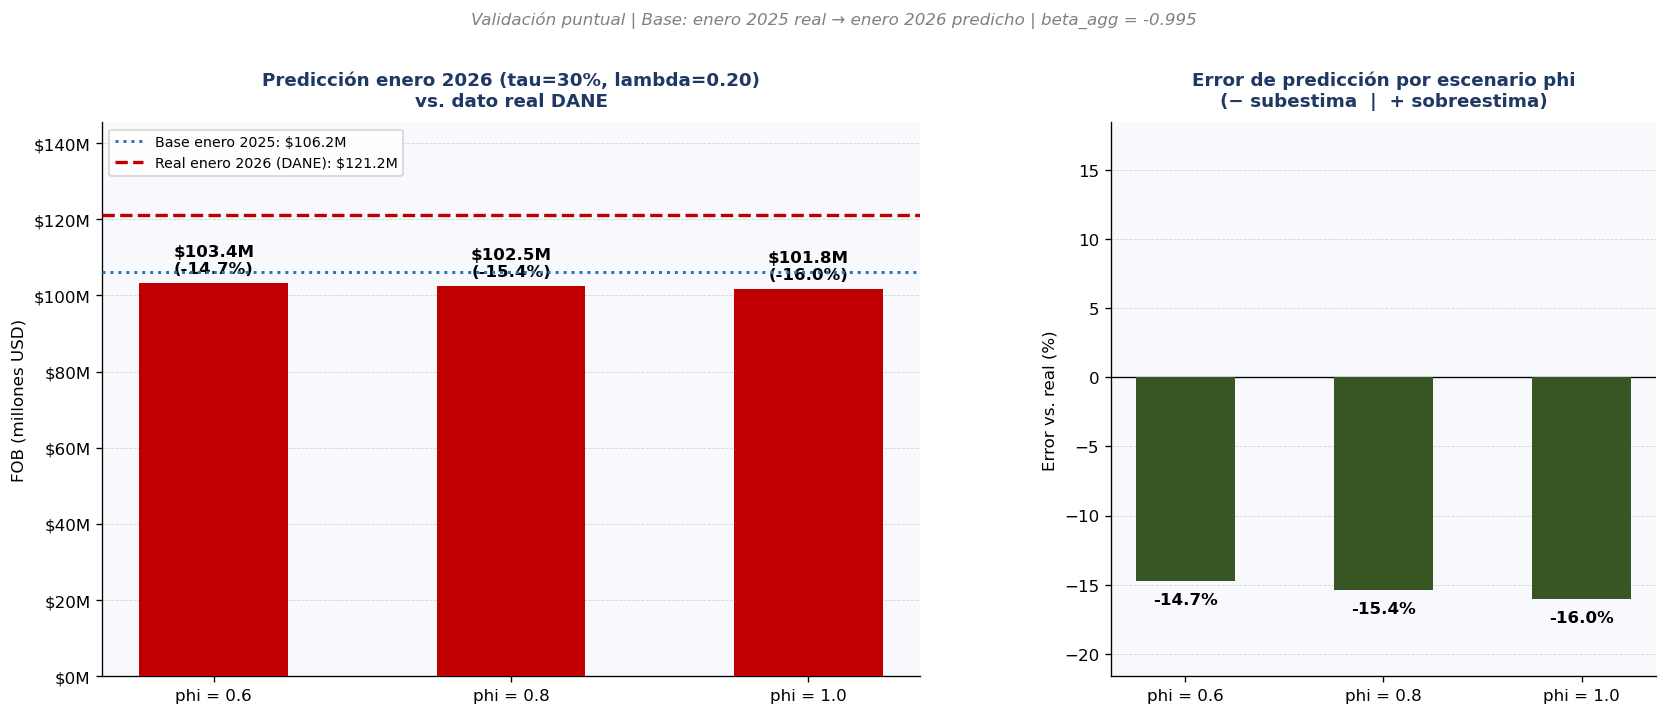

In [11]:
def viz_validacion(validation_jan, save=True):
    df_v   = validation_jan.copy().sort_values("phi")
    phis   = df_v["phi"].round(2).values
    base   = df_v["base_ene25_usd"].iloc[0] / 1e6
    real26 = df_v["real_ene26_usd"].iloc[0] / 1e6
    preds  = df_v["pred_ene26_usd"].astype(float).values / 1e6
    errors = df_v["error_pct"].astype(float).values
    lam    = float(df_v["lambda_enero"].iloc[0])

    x = np.arange(len(phis))
    bar_colors = [GREEN if abs(e) < 5 else (ORANGE if abs(e) < 10 else RED) for e in errors]
    err_colors = [RED if e > 0 else GREEN for e in errors]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8),
                             gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    bars = ax.bar(x, preds, color=bar_colors, width=0.5, zorder=3)
    ax.axhline(base,   color=TEAL, lw=1.8, ls=":", zorder=4,
               label=f"Base enero 2025: ${base:,.1f}M")
    ax.axhline(real26, color=RED,  lw=2.0, ls="--", zorder=4,
               label=f"Real enero 2026 (DANE): ${real26:,.1f}M")

    ymax = max(real26, preds.max()) * 1.20
    ax.set_ylim(0, ymax)
    for bar, pred, err in zip(bars, preds, errors):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ymax * 0.012,
                f"${pred:,.1f}M\n({err:+.1f}%)",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([f"phi = {p:.1f}" for p in phis], fontsize=10)
    ax.set_ylabel("FOB (millones USD)", fontsize=10)
    ax.set_title(f"Predicción enero 2026 (tau=30%, lambda={lam:.2f})\nvs. dato real DANE",
                 fontsize=11, fontweight="bold", color=BLUE, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M"))
    ax.set_facecolor("#F7F9FC")
    ax.grid(axis="y", ls="--", lw=0.5, alpha=0.5, zorder=0)
    ax.legend(fontsize=8.5, loc="upper left")

    ax2 = axes[1]
    bars2 = ax2.bar(x, errors, color=err_colors, width=0.5, zorder=3)
    ax2.axhline(0, color="black", lw=0.8)
    emax = max(abs(errors.min()), abs(errors.max()))
    ax2.set_ylim(-emax * 1.35, emax * 1.15)
    for bar, e in zip(bars2, errors):
        va = "bottom" if e >= 0 else "top"
        ax2.text(bar.get_x() + bar.get_width()/2,
                 e + (emax * 0.05 if e >= 0 else -emax * 0.05),
                 f"{e:+.1f}%", ha="center", va=va,
                 fontsize=10, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"phi = {p:.1f}" for p in phis], fontsize=10)
    ax2.set_ylabel("Error vs. real (%)", fontsize=10)
    ax2.set_title("Error de predicción por escenario phi\n(− subestima  |  + sobreestima)",
                  fontsize=11, fontweight="bold", color=BLUE, pad=10)
    ax2.set_facecolor("#F7F9FC")
    ax2.grid(axis="y", ls="--", lw=0.5, alpha=0.5, zorder=0)

    fig.patch.set_facecolor("white")
    fig.suptitle(
        f"Validación puntual | Base: enero 2025 real → enero 2026 predicho | beta_agg = {beta_agg:.3f}",
        fontsize=10, color="gray", style="italic", y=1.02)
    fig.tight_layout()
    fig.subplots_adjust(top=0.86, wspace=0.28)

    if save:
        path = FIG_DIR / "viz_validacion_enero.png"
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print(f"[VIZ] Guardada: {path.name}")
    plt.show()

viz_validacion(validation_jan)


### 3.3 — Interpretación: front-loading y límites de la validación

Todos los escenarios phi subestiman el real de enero 2026. El modelo predice una caída;
el dato real fue más alto. Esto no invalida el modelo — es evidencia de **front-loading**:
exportadores e importadores adelantaron operaciones antes de la entrada en vigor del arancel,
inflando artificialmente el dato de enero 2026.

El modelo captura el equilibrio estructural de largo plazo. El dato de enero no es ese
equilibrio — es un pico transitorio de 1–2 meses que se revierte en los períodos siguientes.

> **Nota sobre el "mejor phi":** el escenario que produce menor error en enero
> **no** calibra el pass-through real. Un phi bajo produce una caída predicha menor,
> que queda más cerca de un dato inflado por front-loading. El pass-through real
> solo puede calibrarse con datos de equilibrio (Q2 2026 en adelante).

| Período | Comportamiento dominante | ¿Útil para calibrar el modelo? |
|---------|--------------------------|-------------------------------|
| Enero 2026 | Front-loading + tau=30% | ❌ Dato inflado artificialmente |
| Febrero 2026 | Inicio tau=50% + inventarios previos | ⚠️ Parcial — transición |
| Q2 2026 en adelante | Equilibrio post-arancel 50% | ✅ Validación estructural posible |


---
## PARTE 4 — Impacto estructural: base 2025 con tau = 50% y lambda dinámico

### Qué hace esta sección

Aplica el shock arancelario del **50%** — la tasa vigente desde febrero 2026 —
sobre los datos reales de cada mes de 2025 (feb–dic), usando el lambda
correspondiente al trimestre de ese mes.

El resultado responde: *"¿cuánto FOB se habría perdido en ese mes si el arancel
del 50% hubiera estado vigente con esa velocidad de adopción?"*

**Esto no es un forecast de 2026.** Es la estimación del impacto estructural
del arancel sobre una base de comercio conocida y real.

### 4.1 — Base mensual feb–dic 2025 y lambda por mes

La base usa **solo los meses de febrero a diciembre** de 2025. Enero se reservó
para la validación puntual de la Parte 3 (con tau=30%), y se excluye aquí para
evitar mezclar los dos análisis.


In [12]:
df_2025 = df[df["ANIO"] == 2025].copy()

# Base mensual feb-dic 2025 — tau=30% de enero ya fue usado en Parte 3
monthly_base = (
    df_2025[df_2025["MES"] >= 2]
    .groupby(["MES", "HS6", "HS2"], as_index=False)
    .agg(fob_base=("FOB_USD", "sum"), qty_base=("CANTIDAD", "sum"))
)

meses_en_base = sorted(monthly_base["MES"].unique())
print("Mes      | Trimestre | Lambda | Tau aplicado | FOB base")
print("─" * 60)
for m in meses_en_base:
    lam = LAMBDA_SCHEDULE[m]
    fob = monthly_base[monthly_base["MES"] == m]["fob_base"].sum()
    trimestre = "Q1" if m <= 3 else ("Q2" if m <= 6 else ("Q3" if m <= 9 else "Q4"))
    print(f"  {MESES_ES[m]} 2025  | {trimestre}        | {lam:.2f}   "
          f"| {int(TAU_50*100)}%          | ${fob/1e6:,.1f}M")

print(f"\nFOB total feb-dic 2025: ${monthly_base['fob_base'].sum()/1e6:,.1f}M")
print(f"Arancel aplicado      : tau = {int(TAU_50*100)}% en todos los meses")


Mes      | Trimestre | Lambda | Tau aplicado | FOB base
────────────────────────────────────────────────────────────
  Feb 2025  | Q1        | 0.20   | 50%          | $123.1M
  Mar 2025  | Q1        | 0.20   | 50%          | $131.0M
  Abr 2025  | Q2        | 0.60   | 50%          | $135.4M
  May 2025  | Q2        | 0.60   | 50%          | $138.6M
  Jun 2025  | Q2        | 0.60   | 50%          | $134.5M
  Jul 2025  | Q3        | 0.80   | 50%          | $150.5M
  Ago 2025  | Q3        | 0.80   | 50%          | $132.9M
  Sep 2025  | Q3        | 0.80   | 50%          | $157.4M
  Oct 2025  | Q4        | 1.00   | 50%          | $150.2M
  Nov 2025  | Q4        | 1.00   | 50%          | $137.3M
  Dic 2025  | Q4        | 1.00   | 50%          | $169.0M

FOB total feb-dic 2025: $1,560.0M
Arancel aplicado      : tau = 50% en todos los meses


### 4.2 — Cálculo del impacto mensual (tau = 50%, todos los phi)

In [13]:
monthly_impact_rows = []

for mes_val, mes_base_df in monthly_base.groupby("MES"):
    base_mes  = mes_base_df[["HS6", "HS2", "fob_base", "qty_base"]].copy()
    lam_mes   = LAMBDA_SCHEDULE[mes_val]
    trimestre = "Q1" if mes_val<=3 else ("Q2" if mes_val<=6 else ("Q3" if mes_val<=9 else "Q4"))

    # Solo tau=50% — es la única tasa vigente en feb–dic 2026
    for phi_val in PHI_SET:
        impact_mes = apply_tariff_shock(
            base_mes,
            tau=TAU_50,          # 50% en todos los meses feb-dic
            phi=phi_val,
            beta_agg=beta_agg,
            elas_hs=elas_hs,
            lambda_val=lam_mes   # lambda dinámico por mes
        )
        s = summarize_impact(impact_mes)
        s["MES"]        = mes_val
        s["mes_nombre"] = MESES_ES[mes_val]
        s["trimestre"]  = trimestre
        monthly_impact_rows.append(s)

monthly_impact = pd.DataFrame(monthly_impact_rows)
monthly_impact.to_csv(OUT_IMPACT_MONTHLY, index=False, encoding="utf-8-sig")
print(f"[OK] Impacto mensual calculado: {len(monthly_impact):,} filas")

# Vista resumen para el escenario central
pivot = (
    monthly_impact[monthly_impact["phi"] == PHI_CENTRAL]
    [["MES","mes_nombre","trimestre","lambda","fob_delta_pct"]]
    .rename(columns={"fob_delta_pct": f"caida_pct_tau{int(TAU_50*100)}"})
    .round(1)
)
print(f"\nCaída % por mes — tau={int(TAU_50*100)}%, phi={PHI_CENTRAL}")
print(pivot.to_string(index=False))


[OK] Impacto mensual calculado: 33 filas

Caída % por mes — tau=50%, phi=1.0
 MES mes_nombre trimestre  lambda  caida_pct_tau50
   2        Feb        Q1    0.20            -6.90
   3        Mar        Q1    0.20            -7.20
   4        Abr        Q2    0.60           -19.00
   5        May        Q2    0.60           -19.40
   6        Jun        Q2    0.60           -19.60
   7        Jul        Q3    0.80           -25.00
   8        Ago        Q3    0.80           -24.50
   9        Sep        Q3    0.80           -24.20
  10        Oct        Q4    1.00           -28.00
  11        Nov        Q4    1.00           -27.50
  12        Dic        Q4    1.00           -28.60


**Lectura económica de la tabla:**

- En Q1 (Feb–Mar) la caída es de ~7% porque el arancel del 50% recién comenzó
  y los inventarios previos aún están en circulación (lambda = 0.20).
- En Q2 (Abr–Jun) la caída sube a ~19% cuando los nuevos pedidos ya incorporan el costo.
- En Q3 (Jul–Sep) alcanza ~25%.
- En Q4 (Oct–Dic) el efecto es pleno: caídas de entre 27% y 29%.

Los saltos entre trimestres reflejan el cambio de lambda — no cambios en la demanda
ecuatoriana. La demanda estructural (beta) es constante; lo que varía es la velocidad
con que se incorpora el arancel.


### 4.3 — Impacto anual acumulado por escenario phi

In [14]:
annual_rows = []
for phi_val in PHI_SET:
    sub = monthly_impact[monthly_impact["phi"] == phi_val]
    fob_base_total = sub["fob_base"].sum()
    fob_new_total  = sub["fob_new"].sum()
    annual_rows.append({
        "tau":           TAU_50,
        "tau_label":     f"tau={int(TAU_50*100)}%",
        "phi":           phi_val,
        "fob_base":      fob_base_total,
        "fob_new":       fob_new_total,
        "fob_delta_abs": fob_new_total - fob_base_total,
        "fob_delta_pct": ((fob_new_total / fob_base_total) - 1) * 100,
        "nota":          "Lambda dinámico (Q1=0.20, Q2=0.60, Q3=0.80, Q4=1.00) | tau=50% feb-dic",
    })

annual_impact = pd.DataFrame(annual_rows)
annual_impact.to_csv(OUT_IMPACT_ANNUAL, index=False, encoding="utf-8-sig")

print(f"IMPACTO ESTRUCTURAL ANUAL — tau={int(TAU_50*100)}%, base feb-dic 2025")
print(f"Lambda dinámico: Q1=0.20 | Q2=0.60 | Q3=0.80 | Q4=1.00")
print("─" * 70)
print(f"{'phi':>6}  {'FOB base (M)':>14}  {'FOB c/arancel (M)':>18}  "
      f"{'Δ FOB (M)':>11}  {'Δ FOB %':>9}")
print("─" * 70)
for _, r in annual_impact.iterrows():
    print(f"  {r['phi']:>4.1f}   ${r['fob_base']/1e6:>11,.0f}M   "
          f"${r['fob_new']/1e6:>11,.0f}M   "
          f"${r['fob_delta_abs']/1e6:>8,.0f}M  "
          f"{r['fob_delta_pct']:>8.1f}%")


IMPACTO ESTRUCTURAL ANUAL — tau=50%, base feb-dic 2025
Lambda dinámico: Q1=0.20 | Q2=0.60 | Q3=0.80 | Q4=1.00
──────────────────────────────────────────────────────────────────────
   phi    FOB base (M)   FOB c/arancel (M)    Δ FOB (M)    Δ FOB %
──────────────────────────────────────────────────────────────────────
   0.6   $      1,560M   $      1,326M   $    -234M     -15.0%
   0.8   $      1,560M   $      1,273M   $    -287M     -18.4%
   1.0   $      1,560M   $      1,227M   $    -333M     -21.4%


### 4.4 — Visualización: curva de impacto mensual (tau = 50%)

El gráfico muestra la trayectoria del impacto porcentual a lo largo del año.
Los saltos entre trimestres reflejan el cambio de lambda — no variaciones en la demanda.


[VIZ] Guardada: viz_impacto_pct_tau50_lambda_dinamico.png


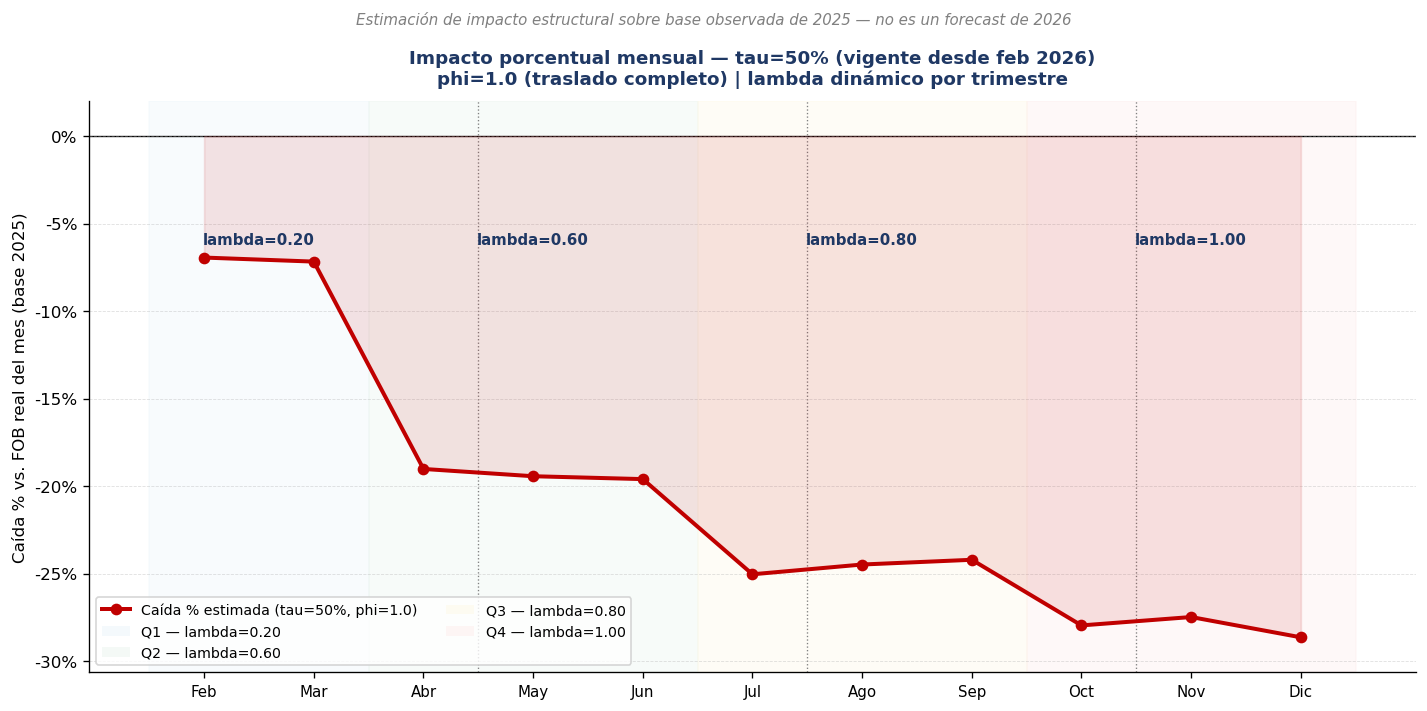

In [15]:
def viz_impacto_mensual_dinamico(monthly_impact, save=True):
    """
    Impacto porcentual mensual — tau=50% (vigente desde febrero 2026),
    phi fijo en PHI_CENTRAL, lambda dinámico por trimestre.
    """
    d = monthly_impact[monthly_impact["phi"] == PHI_CENTRAL].sort_values("MES")
    x    = np.arange(len(d))
    xl   = d["mes_nombre"].values
    dp   = d["fob_delta_pct"].values.astype(float)
    lams = d["lambda"].values

    q_colors = ["#EBF5FB", "#EAF4EE", "#FEF9E7", "#FDEDEC"]
    q_bounds = [(0, 2), (2, 5), (5, 8), (8, 11)]

    fig, ax = plt.subplots(figsize=(12, 6))

    for (xi, xf), qc in zip(q_bounds, q_colors):
        ax.axvspan(xi - 0.5, xf - 0.5, alpha=0.35, color=qc, zorder=0)

    ax.plot(x, dp, "o-", color=RED, lw=2.4, ms=6, zorder=3,
            label=f"Caída % estimada (tau=50%, phi={PHI_CENTRAL})")
    ax.fill_between(x, dp, 0, color=RED, alpha=0.10, zorder=2)
    ax.axhline(0, color="black", lw=0.8, zorder=1)

    for sep in [2.5, 5.5, 8.5]:
        ax.axvline(sep, color="gray", lw=0.8, ls=":", zorder=1)

    y_top = dp.max()
    for (xi, xf) in q_bounds:
        xm  = (xi + xf - 1) / 2
        lam = lams[xi]
        ax.text(xm, y_top + 0.6, f"lambda={lam:.2f}",
                ha="center", va="bottom", fontsize=9, color=BLUE, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(xl, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_ylabel("Caída % vs. FOB real del mes (base 2025)", fontsize=10)
    ax.set_title(
        f"Impacto porcentual mensual — tau=50% (vigente desde feb 2026)\n"
        f"phi={PHI_CENTRAL} (traslado completo) | lambda dinámico por trimestre",
        fontsize=11, fontweight="bold", color=BLUE, pad=10)
    ax.set_ylim(dp.min() - 2, 2)
    ax.grid(axis="y", ls="--", lw=0.5, alpha=0.4, zorder=1)
    ax.set_facecolor("white")

    from matplotlib.patches import Patch
    legend_trim = [
        Patch(facecolor=q_colors[0], alpha=0.5, label="Q1 — lambda=0.20"),
        Patch(facecolor=q_colors[1], alpha=0.5, label="Q2 — lambda=0.60"),
        Patch(facecolor=q_colors[2], alpha=0.5, label="Q3 — lambda=0.80"),
        Patch(facecolor=q_colors[3], alpha=0.5, label="Q4 — lambda=1.00"),
    ]
    ax.legend(handles=[ax.lines[0]] + legend_trim, fontsize=8.5,
              loc="lower left", ncol=2)

    fig.patch.set_facecolor("white")
    fig.suptitle(
        "Estimación de impacto estructural sobre base observada de 2025 — no es un forecast de 2026",
        fontsize=9, color="gray", style="italic", y=0.98)
    fig.tight_layout()

    if save:
        path = FIG_DIR / "viz_impacto_pct_tau50_lambda_dinamico.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"[VIZ] Guardada: {path.name}")
    plt.show()

viz_impacto_mensual_dinamico(monthly_impact)


### 4.5 — Sensibilidad al pass-through por escenario phi

[VIZ] Guardada: viz_phi_sensibilidad_tau50.png


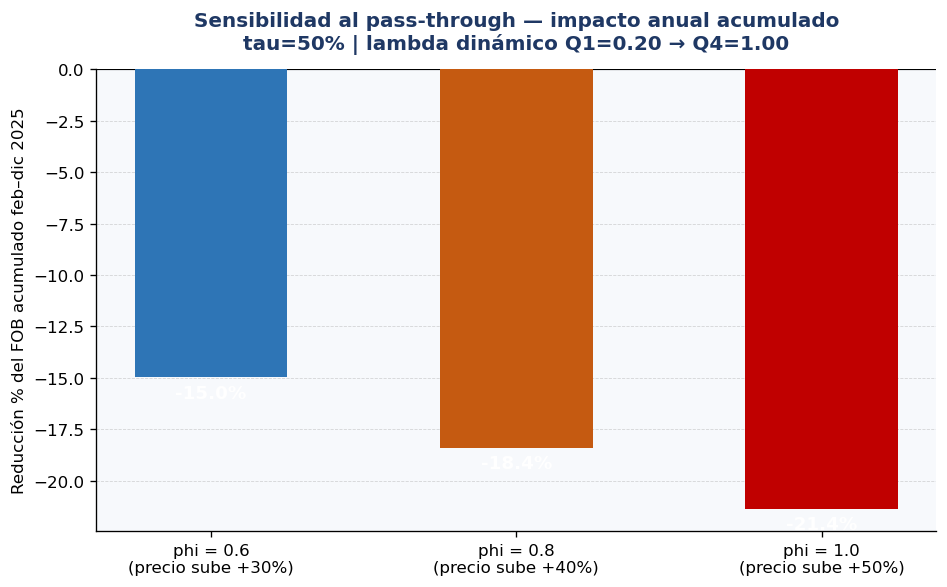

In [16]:
def viz_phi_sensibilidad(annual_impact, save=True):
    """
    Barras de caída % anual acumulada por phi — tau=50% con lambda dinámico.
    """
    d    = annual_impact.sort_values("phi")
    phis = d["phi"].values
    y    = d["fob_delta_pct"].values.astype(float)
    x    = np.arange(len(phis))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(x, y, width=0.5, color=[TEAL, ORANGE, RED], zorder=3)

    for bar, v in zip(bars, y):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width()/2, v - 0.3,
                    f"{v:.1f}%", ha="center", va="top",
                    fontsize=11, fontweight="bold", color="white")

    ax.axhline(0, color="black", lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"phi = {p:.1f}\n(precio sube +{p*50:.0f}%)" for p in phis],
        fontsize=10)
    ax.set_ylabel("Reducción % del FOB acumulado feb–dic 2025", fontsize=10)
    ax.set_title(
        f"Sensibilidad al pass-through — impacto anual acumulado\n"
        f"tau=50% | lambda dinámico Q1=0.20 → Q4=1.00",
        fontsize=12, fontweight="bold", color=BLUE, pad=12)
    ax.grid(axis="y", ls="--", lw=0.5, alpha=0.5, zorder=0)
    ax.set_facecolor("#F7F9FC")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    if save:
        path = FIG_DIR / "viz_phi_sensibilidad_tau50.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"[VIZ] Guardada: {path.name}")
    plt.show()

viz_phi_sensibilidad(annual_impact)


---
## PARTE 5 — Sectores en riesgo: rankings comparativos

Rankings calculados sobre el escenario central (phi = 1.0, tau = 50%) con lambda dinámico.
La base es el FOB anual acumulado feb–dic 2025 (11 meses, cada uno con su lambda propio).

### 5.1 — Top 10 HS6 más afectados por pérdida absoluta de FOB


In [17]:
hs6_annual_rows = []

for mes_val, mes_base_df in monthly_base.groupby("MES"):
    base_mes = mes_base_df[["HS6","HS2","fob_base","qty_base"]].copy()
    lam_mes  = LAMBDA_SCHEDULE[mes_val]
    imp = apply_tariff_shock(
        base_mes, tau=TAU_50, phi=PHI_CENTRAL,
        beta_agg=beta_agg, elas_hs=elas_hs,
        lambda_val=lam_mes
    )
    imp["MES"] = mes_val
    hs6_annual_rows.append(imp)

hs6_annual = pd.concat(hs6_annual_rows, ignore_index=True)

hs6_agg = (
    hs6_annual
    .groupby(["HS6","HS2"])
    .agg(fob_base=("fob_base","sum"), fob_new=("fob_new","sum"))
    .reset_index()
)
hs6_agg["fob_delta_abs"] = hs6_agg["fob_new"] - hs6_agg["fob_base"]
hs6_agg["fob_drop_pct"]  = ((hs6_agg["fob_new"] / hs6_agg["fob_base"]) - 1) * 100

# Ranking por pérdida absoluta (cuánto FOB se pierde en valor)
rank_abs = hs6_agg.sort_values("fob_delta_abs").copy()
# Ranking por caída porcentual (cuáles son más elásticas)
rank_pct = hs6_agg.sort_values("fob_drop_pct").copy()

rank_abs.to_csv(OUT_RANK_HS6, index=False, encoding="utf-8-sig")

print(f"Top 10 HS6 por pérdida ABSOLUTA de FOB — tau=50%, phi={PHI_CENTRAL}")
print(f"(mayor pérdida en dólares — combina elasticidad y tamaño exportador)\n")
(rank_abs.head(10)[["HS6","HS2","fob_base","fob_new","fob_delta_abs","fob_drop_pct"]]
 .rename(columns={"fob_base":"FOB base feb-dic 2025","fob_new":"FOB c/tau=50%",
                  "fob_delta_abs":"Δ FOB absoluto","fob_drop_pct":"Δ FOB %"})
 .round(0))


Top 10 HS6 por pérdida ABSOLUTA de FOB — tau=50%, phi=1.0
(mayor pérdida en dólares — combina elasticidad y tamaño exportador)



,HS6,HS2,FOB base feb-dic 2025,FOB c/tau=50%,Δ FOB absoluto,Δ FOB %
2177,870323,87,"34,434,363.00","13,811,154.00","-20,623,209.00",-60.00
431,300490,30,"60,892,000.00","46,355,256.00","-14,536,743.00",-24.00
2412,961900,96,"20,622,375.00","10,015,831.00","-10,606,544.00",-51.00
1114,600410,60,"22,446,762.00","15,550,403.00","-6,896,358.00",-31.00
93,170490,17,"29,028,204.00","22,417,252.00","-6,610,952.00",-23.00
2012,850710,85,"16,403,905.00","9,960,376.00","-6,443,528.00",-39.00
1755,841810,84,"17,709,417.00","11,695,225.00","-6,014,192.00",-34.00
502,330290,33,"18,351,589.00","12,558,102.00","-5,793,487.00",-32.00
511,330590,33,"24,249,474.00","18,723,265.00","-5,526,209.00",-23.00
3,030342,03,"15,873,821.00","10,496,327.00","-5,377,494.00",-34.00


**Cómo leer este ranking:**

Una subpartida aparece arriba por dos razones simultáneas: por ser grande en la base
exportadora y por ser elástica al precio. No es solo el efecto del arancel — también
refleja el peso de cada sector en el comercio bilateral.

Para ver cuáles son las subpartidas más *elásticas* (independientemente de su tamaño),
revisar la columna `Δ FOB %`. Subpartidas con caídas superiores al 50% tienen
elasticidades cercanas al guardrail inferior (beta ≈ −3.0).


### 5.2 — Top 20 HS6 por caída porcentual estimada (tau = 50%)

[VIZ] Guardada: viz_top_hs6_caida_pct_tau50.png


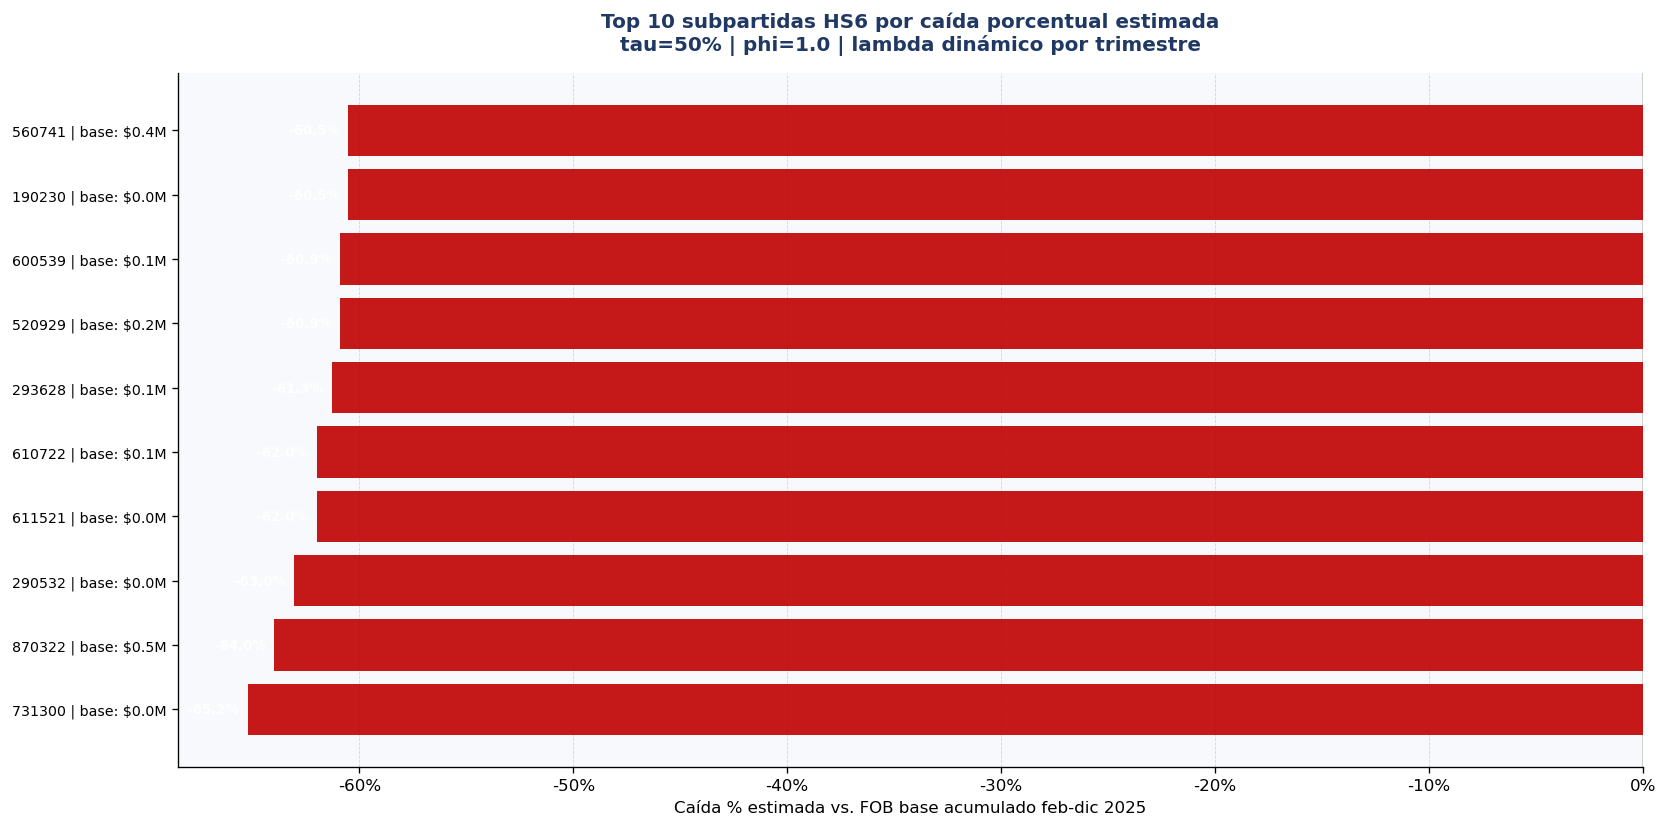

In [21]:
def viz_top_hs6_impacto_pct(rank_pct, top_n=20, save=True):
    """
    Top HS6 por caída porcentual estimada bajo tau=50%, phi=PHI_CENTRAL.
    Ordenado de mayor a menor caída porcentual.
    Las etiquetas incluyen el FOB base para dar contexto de tamaño.
    """
    top = (
        rank_pct.head(top_n)[["HS6","HS2","fob_base","fob_new","fob_drop_pct"]]
        .copy()
        .sort_values("fob_drop_pct", ascending=True)
    )
    impact = top["fob_drop_pct"].values.astype(float)
    y      = np.arange(len(top))
    labels = (top["HS6"] + " | base: $"
              + (top["fob_base"]/1e6).round(1).astype(str) + "M").values

    fig, ax = plt.subplots(figsize=(14, max(7, top_n * 0.60)))
    ax.barh(y, impact, color=RED, alpha=0.9, zorder=3)
    ax.axvline(0, color="black", lw=0.8, zorder=1)

    for i, pct in enumerate(impact):
        ax.text(pct - 0.4, y[i], f"{pct:.1f}%",
                va="center", ha="right", fontsize=8,
                color="white", fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlabel("Caída % estimada vs. FOB base acumulado feb-dic 2025", fontsize=10)
    ax.set_title(
        f"Top {top_n} subpartidas HS6 por caída porcentual estimada\n"
        f"tau=50% | phi={PHI_CENTRAL} | lambda dinámico por trimestre",
        fontsize=12, fontweight="bold", color=BLUE, pad=14)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_facecolor("#F7F9FC")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    if save:
        path = FIG_DIR / "viz_top_hs6_caida_pct_tau50.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"[VIZ] Guardada: {path.name}")
    plt.show()

viz_top_hs6_impacto_pct(rank_pct, top_n=10)


[VIZ] Guardada: viz_publicacion_top10_perdida_absoluta.png


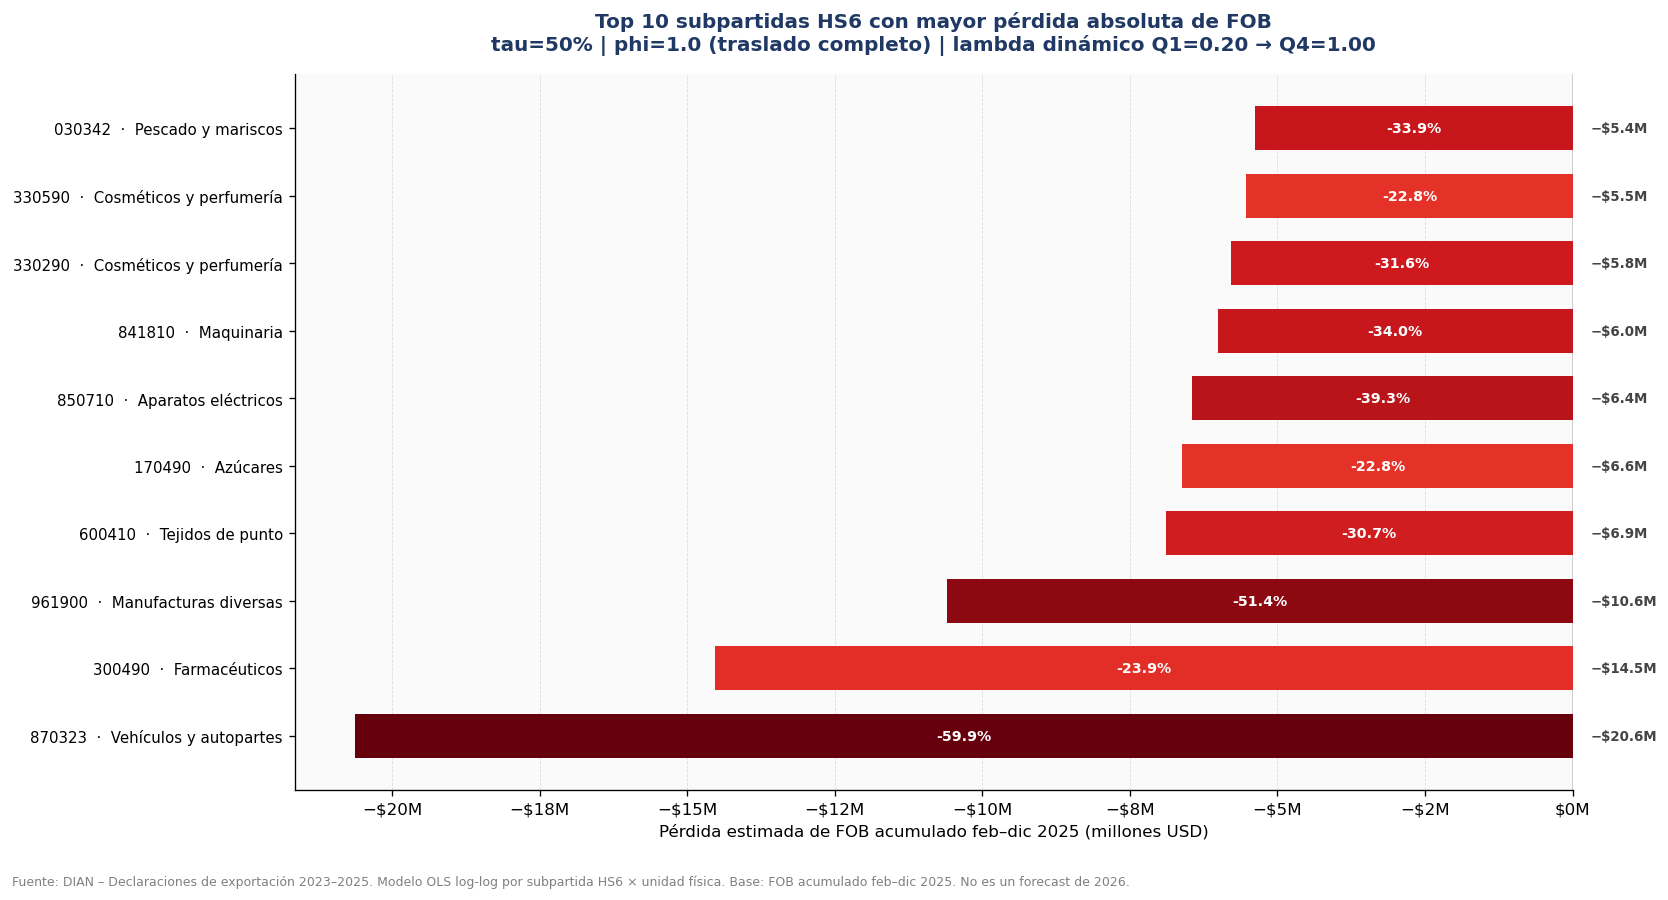

In [23]:
# ============================================================
# GRÁFICO PARA PUBLICACIÓN — Top HS6 por pérdida absoluta de FOB
# ============================================================
# Usa rank_abs (ya calculado en la Parte 5 del notebook v6).
# Ordena por pérdida en USD, no por caída %, para mostrar los
# sectores que realmente mueven el comercio bilateral.
#
# REQUISITO: haber ejecutado las Partes 2–5 del notebook v6.
# Variables necesarias: rank_abs, PHI_CENTRAL, TAU_50, BETA_MIN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# ── Diccionario de descripción por HS2 ───────────────────────────────────────
# Permite etiquetar cada barra con el nombre del sector, no solo el código.
HS2_NOMBRES = {
    "03": "Pescado y mariscos",
    "04": "Lácteos y huevos",
    "08": "Frutas",
    "17": "Azúcares",
    "19": "Prep. de cereales",
    "21": "Prep. alimenticias",
    "22": "Bebidas",
    "25": "Sal, yeso, cemento",
    "28": "Químicos inorgánicos",
    "29": "Químicos orgánicos",
    "30": "Farmacéuticos",
    "32": "Pinturas y barnices",
    "33": "Cosméticos y perfumería",
    "34": "Jabones y detergentes",
    "38": "Químicos diversos",
    "39": "Plásticos",
    "40": "Caucho",
    "48": "Papel y cartón",
    "56": "Textiles no tejidos",
    "57": "Alfombras",
    "60": "Tejidos de punto",
    "61": "Prendas de punto",
    "62": "Prendas de tejido",
    "63": "Otros textiles",
    "64": "Calzado",
    "69": "Cerámica",
    "70": "Vidrio",
    "73": "Manufacturas de hierro",
    "76": "Aluminio",
    "82": "Herramientas metálicas",
    "84": "Maquinaria",
    "85": "Aparatos eléctricos",
    "87": "Vehículos y autopartes",
    "94": "Muebles",
    "96": "Manufacturas diversas",
}


def viz_top_hs6_perdida_absoluta(rank_abs, top_n=15, save=True):
    """
    Top N subpartidas HS6 por pérdida absoluta de FOB estimada.

    Muestra en cada barra:
    - Longitud: pérdida absoluta en millones USD
    - Etiqueta: pérdida % dentro de la barra (color blanco)
    - Etiqueta exterior: pérdida absoluta en USD M
    - Eje Y: código HS6 + nombre del sector (HS2)

    Este ranking combina elasticidad Y tamaño exportador, por lo que
    refleja el impacto real sobre el comercio bilateral — no solo
    cuáles son los productos más elásticos.
    """

    top = rank_abs.head(top_n).copy()

    # Pérdida absoluta en millones USD (valor negativo → barra hacia izquierda)
    delta_m = top["fob_delta_abs"].values.astype(float) / 1e6
    pct     = top["fob_drop_pct"].values.astype(float)
    base_m  = top["fob_base"].values.astype(float) / 1e6

    # Etiqueta: código HS6 + sector HS2
    def label(row):
        hs2_name = HS2_NOMBRES.get(row["HS2"], f"HS2 {row['HS2']}")
        return f"{row['HS6']}  ·  {hs2_name}"

    labels = [label(row) for _, row in top.iterrows()]
    y      = np.arange(len(labels))

    # Paleta: degradado rojo según magnitud de caída
    max_drop = abs(pct.min())
    bar_colors = [
        plt.cm.Reds(0.45 + 0.55 * abs(p) / max_drop)
        for p in pct
    ]

    fig, ax = plt.subplots(figsize=(14, max(7, top_n * 0.72)))

    bars = ax.barh(y, delta_m, color=bar_colors, zorder=3, height=0.65)

    # Etiqueta de caída % dentro de la barra (blanco)
    for i, (bar, p) in enumerate(zip(bars, pct)):
        bw = bar.get_width()
        if abs(bw) > 0.5:   # solo si la barra tiene espacio
            ax.text(
                bw / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{p:.1f}%",
                ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white"
            )

    # Etiqueta de pérdida absoluta a la derecha de cada barra
    for bar, d in zip(bars, delta_m):
        ax.text(
            0.3,
            bar.get_y() + bar.get_height() / 2,
            f"−${abs(d):,.1f}M",
            ha="left", va="center",
            fontsize=8, color="#444", fontweight="bold"
        )

    # Eje X: millones USD con signo negativo correcto
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"−${abs(v):,.0f}M" if v < 0 else f"${v:,.0f}M"
        )
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(
        "Pérdida estimada de FOB acumulado feb–dic 2025 (millones USD)",
        fontsize=10
    )

    # Título con contexto completo
    ax.set_title(
        f"Top {top_n} subpartidas HS6 con mayor pérdida absoluta de FOB\n"
        f"tau=50% | phi={PHI_CENTRAL} (traslado completo) | "
        f"lambda dinámico Q1=0.20 → Q4=1.00",
        fontsize=12, fontweight="bold", color="#1F3864", pad=14
    )

    # Línea base en cero
    ax.axvline(0, color="black", lw=0.8, zorder=1)

    # Grid sutil
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4, zorder=0)
    ax.set_facecolor("#FAFAFA")
    fig.patch.set_facecolor("white")

    # Nota al pie
    fig.text(
        0.01, -0.02,
        f"Fuente: DIAN – Declaraciones de exportación 2023–2025. "
        f"Modelo OLS log-log por subpartida HS6 × unidad física. "
        f"Base: FOB acumulado feb–dic 2025. "
        f"No es un forecast de 2026.",
        fontsize=7.5, color="gray", va="top"
    )

    fig.tight_layout()

    if save:
        path = FIG_DIR / f"viz_publicacion_top{top_n}_perdida_absoluta.png"
        fig.savefig(path, dpi=180, bbox_inches="tight")
        print(f"[VIZ] Guardada: {path.name}")

    plt.show()


# ── Ejecutar ──────────────────────────────────────────────────────────────────
viz_top_hs6_perdida_absoluta(rank_abs, top_n=10)

---
## Resumen ejecutivo

In [25]:
print("=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)
print(f"\nElasticidad agregada (beta, ponderada FOB 2023-2025): {beta_agg:.4f}")
print(f"Un arancel que sube el precio 10% → FOB cae ~{abs(beta_agg)*10:.1f}%")
print(f"Pass-through central (phi): {PHI_CENTRAL} (traslado completo al precio)")
print(f"Lambda: dinámico (Q1=0.20 | Q2=0.60 | Q3=0.80 | Q4=1.00)")

print(f"\n{'─'*70}")
print(f"VALIDACIÓN — Enero 2026 | tau=30% | lambda={LAMBDA_ENERO_VALIDACION}")
print(f"{'─'*70}")
print(validation_jan[["phi","lambda_enero","base_ene25_usd","real_ene26_usd",
                        "pred_ene26_usd","error_pct"]].round(0).to_string(index=False))
print("  → Todos los escenarios subestiman el real: evidencia de front-loading.")
print("  → El 'mejor phi' en enero no calibra el pass-through real.")
print("  → Validación definitiva pendiente con datos Q2 2026.")

print(f"\n{'─'*70}")
print(f"IMPACTO ESTRUCTURAL — tau=50% | feb-dic 2025 | lambda dinámico")
print(f"{'─'*70}")
print("  (Estimación del efecto del arancel sobre base real — NO forecast de 2026)")
for _, r in annual_impact.iterrows():
    print(f"  phi={r['phi']:.1f}  →  FOB cae {r['fob_delta_pct']:+.1f}%  "
          f"(−${abs(r['fob_delta_abs'])/1e6:,.0f}M vs. base feb-dic 2025)")

print(f"\n{'─'*70}")
print(f"TOP 5 HS6 por pérdida absoluta  (tau=50%, phi={PHI_CENTRAL}, lambda dinámico)")
print(f"{'─'*70}")
print(rank_abs.head(5)[["HS6","HS2","fob_base","fob_new","fob_delta_abs","fob_drop_pct"]]
      .round(1).to_string(index=False))

central = annual_impact[annual_impact["phi"] == PHI_CENTRAL]

total_loss = central["fob_delta_abs"].sum()

print(f"\nFOB total estimado perdido (phi={PHI_CENTRAL}): "
      f"−${abs(total_loss)/1e6:,.0f}M USD")
print("\n[FIN]")


RESUMEN EJECUTIVO

Elasticidad agregada (beta, ponderada FOB 2023-2025): -0.9948
Un arancel que sube el precio 10% → FOB cae ~9.9%
Pass-through central (phi): 1.0 (traslado completo al precio)
Lambda: dinámico (Q1=0.20 | Q2=0.60 | Q3=0.80 | Q4=1.00)

──────────────────────────────────────────────────────────────────────
VALIDACIÓN — Enero 2026 | tau=30% | lambda=0.2
──────────────────────────────────────────────────────────────────────
 phi  lambda_enero  base_ene25_usd  real_ene26_usd  pred_ene26_usd  error_pct
1.00          0.00  106,180,094.00       121200000  103,364,251.00     -15.00
1.00          0.00  106,180,094.00       121200000  102,548,019.00     -15.00
1.00          0.00  106,180,094.00       121200000  101,781,761.00     -16.00
  → Todos los escenarios subestiman el real: evidencia de front-loading.
  → El 'mejor phi' en enero no calibra el pass-through real.
  → Validación definitiva pendiente con datos Q2 2026.

──────────────────────────────────────────────────────────

---
## PARTE 6 — Metodología, supuestos y limitaciones

### 6.1 — Estimador: OLS log-log por celda HS6 × unidad física

    ln(cantidad_t) = alpha + beta × ln(precio_unitario_t) + epsilon_t

`beta` = elasticidad-precio de la demanda ecuatoriana. Se estima con datos mensuales
2023–2025 (hasta 34 observaciones por celda). El lambda dinámico se aplica después
de estimar beta — son pasos independientes.

| # | Supuesto | Consecuencia si se viola |
|---|----------|--------------------------|
| 1 | Price-taking: Colombia sin poder de mercado en Ecuador | Sesgo de simultaneidad — beta subestimado en valor absoluto |
| 2 | OLS sin corrección de endogeneidad | Sesgo de atenuación aceptado |
| 3 | Estacionariedad implícita (niveles log) | Con ≤ 34 meses los tests de raíz unitaria tienen poco poder |
| 4 | Sin efectos fijos temporales | Inflación y tipo de cambio pueden contaminar beta |

**Mitigaciones:** winsorización 2–98%, guardrails beta ∈ [−3.0, −0.1], mínimo 18 obs por celda.

---

### 6.2 — Mecanismo del shock arancelario

    shock_log      = lambda_mes × ln(1 + phi × tau)
    qty_multiplier = exp(beta × shock_log)
    fob_nuevo      = fob_base × qty_multiplier

**phi** y **lambda** son multiplicativos en el shock: `phi=0.8, lambda=0.6` produce
el mismo número que `phi=0.48, lambda=1.0`. La diferencia es conceptual: phi describe
*quién* absorbe el costo; lambda describe *cuándo* llega el efecto.

---

### 6.3 — Lambda dinámico: supuesto y sensibilidad

El schedule de lambda es un **supuesto externo** — no se estima de los datos.
Refleja un juicio sobre la velocidad de adaptación del comercio bilateral ante un
arancel nuevo. Los valores elegidos son conservadores en Q1 (contratos vigentes,
inventarios pre-comprados) y crecientes hacia el efecto pleno en Q4.

Para sensibilizar este supuesto: modificar `LAMBDA_SCHEDULE` en la sección 2.2
y re-ejecutar las Partes 4 y 5. Las elasticidades (Parte 2) no cambian.

---

### 6.4 — Estructura arancelaria reflejada en el modelo

| Período | Tasa (tau) | Parte del análisis |
|---------|-----------|-------------------|
| Enero 2026 | 30% | Parte 3 — validación puntual contra dato real DANE |
| Feb–Dic 2026 | 50% | Parte 4 — estimación de impacto estructural |

Esta distinción refleja el contexto real: Ecuador aplicó 30% en enero como medida
inicial y la endureció al 50% desde febrero. Mezclar las dos tasas en un solo
análisis distorsionaría tanto la validación (que requiere 30%) como la estimación
de impacto de largo plazo (que debe usar 50%).

---

### 6.5 — Advertencia sobre la interpretación del "mejor phi" en enero

El escenario con menor error absoluto en la validación de enero 2026 no es evidencia
del pass-through real. El dato de enero está distorsionado por front-loading — cualquier
phi bajo producirá una caída predicha menor que queda más cerca del dato inflado.
El pass-through real solo puede calibrarse con datos de equilibrio (Q2 2026 en adelante).

---

### 6.6 — Limitaciones y próximos pasos

| Limitación | Impacto sobre los resultados | Cuándo se puede resolver |
|------------|------------------------------|--------------------------|
| Solo 1 mes real de validación (enero 2026) | No se puede calibrar phi con precisión | Con datos Q2 2026 (DANE) |
| Front-loading distorsiona enero 2026 | Dato de validación no es de equilibrio | Q2 2026 |
| Lambda es supuesto, no estimado | Rango de incertidumbre adicional no cuantificado | Nunca con esta fuente |
| Sin datos de sustitución de proveedores | Modelo asume que Ecuador no sustituye a Colombia | Nunca con esta fuente |
| Base 2025 ≠ demanda base 2026 | El % de caída es robusto; el nivel absoluto puede variar | Con datos 2026 (DANE) |
